<a href="https://colab.research.google.com/github/devesh-khemani/evesh-khemani-Bayesian-Sensor-Fusion-for-Autonomous-Swarm-Threat-Mapping/blob/main/swarm_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

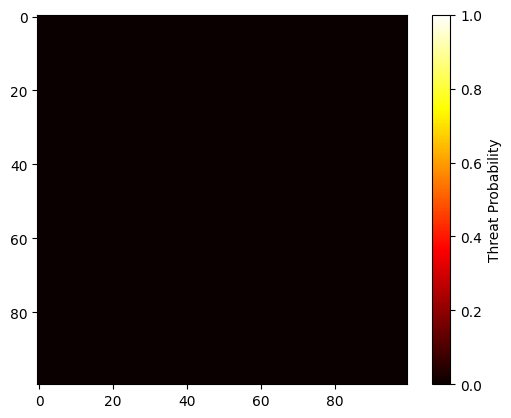

Threat map data saved to threat_map.csv
Sniper coordinates saved to snipers.csv


In [1]:
#intial set up - the functions that we will activley need to call in the algorithm are in the below box

import numpy as np
import matplotlib.pyplot as plt
import time
import csv
import random
import math
m_temp_sniper = 40
sigma_sniper = 5
m_temp_no_sniper = 18
sigma_no_sniper = 5
k = 0.1  # noise scale factor (tune this)
mu_camera_sniper = 0.9   # mean detection probability if sniper is present
sigma_camera_sniper = 0.05

mu_camera_no_sniper = 0.1  # mean detection probability if no sniper
sigma_camera_no_sniper = 0.05

k_camera = 0.002  # noise growth factor per unit distance (tune this)



def define_map():

  grid_size = (100, 100)
  threat_map = np.zeros(grid_size)  # All probabilities start at 0

  # Example: add some random threats

  plt.imshow(threat_map, cmap='hot', interpolation='nearest', vmin=0, vmax=1)
  plt.colorbar(label='Threat Probability')
  plt.show()
  return threat_map

threat_map = define_map()


def generate_map():
  rows, cols = 100, 100

  # Base environment temperature and probability
  BASE_TEMP = 18.0
  BASE_PROB = 0.015

  # Define sniper locations (random or fixed)
  snipers = [(30, 40), (70, 80)]  # example sniper coords (row, col)

  # Define fake hotspots (no sniper there, but higher temp/prob)
  fake_hotspots = [(20, 20), (50, 50), (80, 30)]

  def generate_value(r, c):
      # Start with base values
      temp = BASE_TEMP
      prob = BASE_PROB

      # If this cell is a sniper location: high temp and prob
      if (r, c) in snipers:
          temp += 10  # e.g., 28.0
          prob += 0.3  # higher chance drone thinks sniper is here

      # If fake hotspot: moderate increase
      elif (r, c) in fake_hotspots:
          temp += 6
          prob += 0.1

      else:
          # Surrounding cells around hotspots might have slightly increased values (simulate diffusion)
          for hx, hy in snipers + fake_hotspots:
              dist = abs(r - hx) + abs(c - hy)
              if dist < 5 and dist > 0:
                  temp += (5 - dist) * 0.5
                  prob += (5 - dist) * 0.01

      # Add some noise to simulate false negatives/uncertainty
      prob += random.uniform(-0.005, 0.005)
      prob = max(prob, 0)  # probability can't be negative
      prob = min(prob, 1)  # can't exceed 1

      return [round(temp, 2), round(prob, 3)]


  # Generate grid
  data = []
  for r in range(rows):
      row = []
      for c in range(cols):
          val = generate_value(r, c)
          row.append(f"{val[0]};{val[1]}")
      data.append(row)

  # Save to CSV
  csv_filename = 'threat_map.csv'
  with open(csv_filename, 'w', newline='') as csvfile:
      writer = csv.writer(csvfile)
      writer.writerows(data)

  print(f"Threat map data saved to {csv_filename}")

  # Save sniper coords separately
  with open('snipers.csv', 'w', newline='') as csvfile:
      writer = csv.writer(csvfile)
      writer.writerow(['row', 'col'])
      for coord in snipers:
          writer.writerow(coord)

  print("Sniper coordinates saved to snipers.csv")


def load_data_from_csv(filename):
    data = []
    with open(filename, 'r', newline='') as csvfile:
        reader = csv.reader(csvfile)
        for row in reader:
            data.append(row)
    return data

def get_cell_data(data, x, y):

    cell_str = data[y][x]
    temp_str, prob_str = cell_str.split(';')
    return [float(temp_str), float(prob_str)]

def initial_p_s_map():    #getting the intial probability map
  p_s_map = []
  initial_p = 1/(100*100)
  column = []

  for col in range(100):
    column.append(initial_p)

  for row in range(100):
    p_s_map.append(column.copy())

  return p_s_map

def p_n_map_generator():
  p_n_map = []
  for col in p_s_map:
    temp = []
    for row in range(100):
      x = col[row]
      x = 1-x
      temp.append(x)  #P(sniper or no sniper adds to one)
    p_n_map.append(temp)

  return p_n_map

def gaussian(x, mu, sigma):
    x = float(x)
    return (1 / (math.sqrt(2 * math.pi) * sigma)) * math.exp(-((x - mu) ** 2) / (2 * sigma ** 2)) #returns probability

def distance_uncertainty(x, mu, sigma_class, d, k):
    sigma_eff = math.sqrt(sigma_class**2 + k * d**2)  # as distance increases, we are increasing the standard deviation - greater uncertainty
    return gaussian(x, mu, sigma_eff) #then putting standard deviation in guassian model

def temp(x, y):
  cell_data = data[y][x]
  cell_data = cell_data.split(";")

  return cell_data[0]

def camera_score(x, y):
  cell_data = data[y][x]
  cell_data = cell_data.split(";")

  return cell_data[1]

def distance_finder(x1, y1, x2, y2):
  return math.sqrt(((x2-x1)**2 + (y2-y1)**2))    #pythagoras


def update_maps(p_s, x, y):
  p_s_map[y][x] = p_s
  p_n_map[y][x] = 1-p_s

  #now gotta update the whole map to make all the probabilities add to 1

def fuse_probabilities(p1, p2):   #uses bayes
    numerator = p1 * p2
    denominator = numerator + (1 - p1) * (1 - p2)
    if denominator == 0:
        return 0.0  # avoid division by zero; means no info or conflict
    return numerator / denominator


generate_map()

data = load_data_from_csv('threat_map.csv')



p_s_map = initial_p_s_map()
p_n_map = p_n_map_generator()

In [ ]:
def p_sniper(drone_x, drone_y, goal_x, goal_y):

  measured_temp = temp(goal_x, goal_y)  # measured temperature sensor reading
  distance = distance_finder(drone_x, drone_y, goal_x, goal_y)  # distance (meters, for example)


  prior_p_no_sniper = p_n_map[goal_y][goal_x]
  prior_p_sniper = p_s_map[goal_y][goal_x]


  P_sniper = distance_uncertainty(measured_temp, m_temp_sniper, sigma_sniper, distance, k)
  P_no_sniper = distance_uncertainty(measured_temp, m_temp_no_sniper, sigma_no_sniper, distance, k)

  posterior_s_temp = (P_sniper * prior_p_sniper) / (P_sniper * prior_p_sniper + P_no_sniper * prior_p_no_sniper)  #bayes theorum: posterior = ....




  measured_camera = camera_score(goal_x, goal_y)
  P_s = distance_uncertainty(measured_camera, mu_camera_sniper, sigma_camera_sniper, distance, k_camera)
  P_n = distance_uncertainty(measured_camera, mu_camera_no_sniper, sigma_camera_no_sniper, distance, k_camera)

  posterior_s = (P_s * prior_p_sniper) / (P_s * prior_p_sniper + P_n * prior_p_no_sniper)


  probability_sniper = fuse_probabilities(posterior_s_temp, posterior_s)
  update_maps(probability_sniper, goal_x, goal_y)
  print(probability_sniper)


def plot_drones(drones): #where drones = [(5*i, 5), ()...]

  for i in range(5):
    plt.imshow(threat_map, cmap='hot', interpolation='nearest')
    for x, y in drones:
        plt.plot(y, x, 'bo')  # Blue dots for drones
    plt.show()

p_sniper(0, 0, 3, 4)

3 4
[[0.0001, 0.0001, 0.0001, 6.705890716833665e-38, 0.0001, 0.0001, 0.0001, 0.0001, 0.0001, 0.0001, 0.0001, 0.0001, 0.0001, 0.0001, 0.0001, 0.0001, 0.0001, 0.0001, 0.0001, 0.0001, 0.0001, 0.0001, 0.0001, 0.0001, 0.0001, 0.0001, 0.0001, 0.0001, 0.0001, 0.0001, 0.0001, 0.0001, 0.0001, 0.0001, 0.0001, 0.0001, 0.0001, 0.0001, 0.0001, 0.0001, 0.0001, 0.0001, 0.0001, 0.0001, 0.0001, 0.0001, 0.0001, 0.0001, 0.0001, 0.0001, 0.0001, 0.0001, 0.0001, 0.0001, 0.0001, 0.0001, 0.0001, 0.0001, 0.0001, 0.0001, 0.0001, 0.0001, 0.0001, 0.0001, 0.0001, 0.0001, 0.0001, 0.0001, 0.0001, 0.0001, 0.0001, 0.0001, 0.0001, 0.0001, 0.0001, 0.0001, 0.0001, 0.0001, 0.0001, 0.0001, 0.0001, 0.0001, 0.0001, 0.0001, 0.0001, 0.0001, 0.0001, 0.0001, 0.0001, 0.0001, 0.0001, 0.0001, 0.0001, 0.0001, 0.0001, 0.0001, 0.0001, 0.0001, 0.0001, 0.0001], [0.0001, 0.0001, 0.0001, 6.705890716833665e-38, 0.0001, 0.0001, 0.0001, 0.0001, 0.0001, 0.0001, 0.0001, 0.0001, 0.0001, 0.0001, 0.0001, 0.0001, 0.0001, 0.0001, 0.0001, 0.0001, 0.

In [ ]:
import numpy as np

def mediate_nums_np(grid):
    arr = np.array(grid, dtype=float)
    total = arr.sum()
    if total == 0:
        raise ValueError("Total is zero.")
    arr /= total
    return arr.tolist()




p_s_map = mediate_nums(p_s_map)

final_total = sum(sum(row) for row in p_s_map)
print("final total:", final_total)


final total: 1.6616603254790635e-43


In [ ]:
#now figure out how we can make multiple drones move at the same time.
#can do the computation first, then display the drones paths

3 4


'18.0'

In [ ]:
#then implement the algorithm